<a href="https://colab.research.google.com/github/ivanriuk/Tarea4_Optimizacion2/blob/main/ExactMDVRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import Pkg; Pkg.add("HiGHS")
import Pkg; Pkg.add("JuMP")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [60]:
function read_mdvrp_instance(filepath::String)
    # Convertir cada línea en vector de enteros
    data = [parse.(Float64, split(fila)) for fila in readlines(filepath)]

    # =========================
    # Primera fila
    # =========================
    first_row = data[1]
    type       = Int(first_row[1])
    truck_num  = Int(first_row[2])
    client_num = Int(first_row[3])
    depot_num  = Int(first_row[4])

    # =========================
    # Filas de capacidades
    # =========================
    cap_start = 2
    cap_end   = 1 + depot_num

    capacities = [data[i][2] for i in cap_start:cap_end]

    # =========================
    # Filas de clientes
    # =========================
    client_start = cap_end + 1
    client_end   = client_start + client_num - 1

    index     = Vector{Int}(undef, client_num)
    positions = Matrix{Float64}(undef, client_num, 2)
    weights   = Vector{Float64}(undef, client_num)

    for (j, i) in enumerate(client_start:client_end)
        row = data[i]
        index[j]        = Int(row[1])   #indice
        positions[j, 1] = row[2]   # x
        positions[j, 2] = row[3]   # y
        weights[j]      = row[5]   # weight
    end

    #clients = hcat(index, positions, weights)

    # =========================
    # Filas de depósitos
    # =========================
    depot_start = client_end + 1
    depot_end   = depot_start + depot_num - 1

    depots = Matrix{Float64}(undef, depot_num, 3)

    for (j, i) in enumerate(depot_start:depot_end)
        row = data[i]
        depots[j, 1] = j           #index
        depots[j, 2] = row[2]      #x
        depots[j, 3] = row[3]      #y
    end

    # =========================
    # Matriz coordenadas
    # =========================
    coord = Matrix{Float64}(undef, client_num + depot_num, 2)

    coord = [positions;
              depots[:,2:3]]

    return (
        type = type,
        truck_num = truck_num,
        client_num = client_num,
        depot_num = depot_num,
        capacities = capacities,
        positions = positions,
        weights = weights,
        depots = depots,
        coord = coord
    )
end

read_mdvrp_instance (generic function with 1 method)

In [90]:
instance = read_mdvrp_instance("/content/Instances/pfbo")

(type = 2, truck_num = 4, client_num = 50, depot_num = 4, capacities = [80.0, 80.0, 80.0, 80.0], positions = [37.0 52.0; 49.0 49.0; … ; 48.0 28.0; 56.0 37.0], weights = [7.0, 30.0, 16.0, 9.0, 21.0, 15.0, 19.0, 23.0, 11.0, 5.0  …  27.0, 13.0, 11.0, 16.0, 10.0, 5.0, 25.0, 17.0, 18.0, 10.0], depots = [1.0 20.0 20.0; 2.0 30.0 40.0; 3.0 50.0 30.0; 4.0 60.0 50.0], coord = [37.0 52.0; 49.0 49.0; … ; 50.0 30.0; 60.0 50.0])

In [91]:
truck_num = instance.truck_num
client_num = instance.client_num
depot_num = instance.depot_num
capacity = instance.capacities
weights = instance.weights
coord = instance.coord
positions = instance.positions
depots = instance.depots

4×3 Matrix{Float64}:
 1.0  20.0  20.0
 2.0  30.0  40.0
 3.0  50.0  30.0
 4.0  60.0  50.0

# We calculate de distance matrix betweeen nodes ands depots

In [63]:
import Pkg; Pkg.add("Distances")
using Distances

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [92]:
cost = pairwise(Euclidean(), coord, dims=1) #matriz costos

for i in 1:size(cost,1)
	cost[i,i] = Inf
end

In [93]:
using JuMP
using HiGHS

"""
Construye un modelo MDVRP basado en la formulación corregida del paper.

Entradas
--------
cost        :: Matrix{Float64}   # matriz de costos
truck_num   # número de camiones por depósito
client_num  # número de clientes
depot_num   # número de depositos
weights     # vector de pesos de clientes
capacity    # vector con capacidad por camión para cada depósito

"""

function build_mdvrp_model(
    cost::Matrix{Float64},
    truck_num::Int,
    client_num::Int,
    depot_num::Int,
    weights::Vector{Float64},
    capacity::Vector{Float64}  # capacidad por vehiculo del deposito d
    )

    # Conjuntos
    I = 1:client_num                                  # idx clientes
    J = (client_num + 1):(client_num + depot_num)     # idx depots
    V = 1:(client_num + depot_num)                    #clientes + depots
    D = 1:depot_num                                   # depots
    K = 1:truck_num                                   # vehículos por deposito


    model = Model(HiGHS.Optimizer)

    # =========================
    # Variables
    # =========================
    @variable(model, x[V, V, K, D], Bin)   # x[i,j,k] = 1 si k usa el arco i->j
    @variable(model, y[I, K, D], Bin)
    @variable(model, u[I, K, D] >= 0)   # variable auxiliar U

    # =========================
    # Función objetivo
    # =========================
    @objective(model, Min,
        sum(cost[i, j] * x[i, j, k, d] for i in V,
            j in V,
            k in K,
            d in D if i != j)
        )

    # No self-loops
    @constraint(model, [i in V, k in K, d in D],
     x[i, i, k, d] == 0
    )

    # NO depósito -> depósito
    @constraint(model,
              [i in J, j in J, k in K, d in D; i != j],
              x[i, j, k, d] == 0)

    # =========================
    # Cada cliente visitado una vez
    # =========================
    @constraint(model, [i in I],
          sum(y[i,k,d] for d in D,
              k in K) == 1)

    # =========================
    # Asegurar continuidad. Indica vehiculo entra y luego sale SOLO UNA VEZ por nodo
    # =========================

    @constraint(model, [i in I, k in K, d in D],
          sum(x[i,j,k,d] for j in V if j != i) == y[i,k,d])

    @constraint(model, [i in I, k in K, d in D],
          sum(x[j,i,k,d] for j in V if j != i) == y[i,k,d])

    # =========================
    # Asegurar salida y regreso unica de vehiculo al deposito
    # =========================
    depot_aux(d) = client_num + d

    @constraint(model, [k in K, d in D],
        sum(x[depot_aux(d), j, k, d] for j in I) <= 1
    )

    @constraint(model, [k in K, d in D],
        sum(x[j, depot_aux(d), k, d] for j in I) <= 1
    )

    # =========================
    # Asegurar salida y regreso al deposito
    # =========================
    """
    @constraint(model, [k in K, d in D],
    sum(x[depot_aux(d), j, k, d] for j in I) ==
    sum(x[j, depot_aux(d), k, d] for j in I)
    )
    """

    # =========================
    # Carga acumulada de la ruta
    # =========================
    @constraint(model, [i in I, k in K, d in D],
        weights[i] * y[i,k,d] <= u[i,k,d]
    )

    @constraint(model, [i in I, k in K, d in D],
        u[i,k,d] <= capacity[d] * y[i,k,d]
    )

    # =========================
    # (4) Eliminación de subtours
    # =========================
    @constraint(model, [i in I, j in I, k in K, d in D; i != j],
        u[i,k,d] - u[j,k,d] + capacity[d] * x[i,j,k,d] <= capacity[d] - weights[j]
    )


    return model, x, u
end

build_mdvrp_model (generic function with 1 method)

In [ ]:
model, x, u = build_mdvrp_model(
    cost,
    truck_num,
    client_num,
    depot_num,
    weights,
    capacity
    )

# The model is optimized using JuMP and HiGHS

In [95]:
optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 43554 rows; 48256 cols; 212256 nonzeros; 47456 integer variables (47456 binary)
Coefficient ranges:
  Matrix  [1e+00, 8e+01]
  Cost    [2e+00, 9e+01]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 8e+01]
Presolving model
42498 rows, 47200 cols, 211200 nonzeros 0s
42498 rows, 44000 cols, 208000 nonzeros 5s
Presolve reductions: rows 42498(-1056); columns 44000(-4256); nonzeros 208000(-4256) 

Solving MIP model with:
   42498 rows
   44000 cols (43200 binary, 0 integer, 0 implied int., 800 continuous, 0 domain fixed)
   208000 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial p

# We obtain the total length

In [121]:
println("Distancia total recorrida = ", objective_value(model))
println()
println("Solve time: ", solve_time(model), " seconds")

Distancia total recorrida = 757.2508620885333

Solve time: 3374.7650389671326 seconds


In [ ]:
x_val = value.(x)

# We visualize the route

In [117]:
using Plots
using Colors

function plot_mdvrp_solution(
    positions::Matrix{<:Real},
    x_val,
    client_num::Int,
    depot_num::Int;
    threshold::Float64 = 0.5,
    save_path::Union{Nothing,String} = nothing
)
    n_nodes = client_num + depot_num

    @assert size(positions, 1) == n_nodes "positions debe tener una fila por nodo"
    @assert size(positions, 2) == 2 "positions debe tener exactamente 2 columnas: x, y"

    I = 1:client_num
    J = (client_num + 1):n_nodes

    num_trucks = size(x_val, 3)
    num_depots = size(x_val, 4)
    total_vehicle_routes = num_trucks * num_depots

    colors = distinguishable_colors(total_vehicle_routes)

    p = plot(
        xlabel = "X",
        ylabel = "Y",
        title = "MDVRP Solution",
        legend = :outerright,
        aspect_ratio = :equal,
        size = (800, 600)
    )

    # Graficar clientes
    scatter!(
        p,
        positions[I, 1],
        positions[I, 2],
        label = "Clients",
        markersize = 4,
        markercolor = :black
    )

    # Graficar depósitos
    scatter!(
        p,
        positions[J, 1],
        positions[J, 2],
        label = "Depots",
        markersize = 8,
        markershape = :square,
        markercolor = :red
    )


    color_idx = 1

    # Dibujar rutas activas
    for d in 1:num_depots
        for k in 1:num_trucks
            used = false

            for i in 1:n_nodes
                for j in 1:n_nodes
                    if i != j && x_val[i, j, k, d] > threshold
                        plot!(
                            p,
                            [positions[i, 1], positions[j, 1]],
                            [positions[i, 2], positions[j, 2]],
                            linewidth = 2.5,
                            color = colors[color_idx],
                            label = used ? false : ""
                        )
                        used = true
                    end
                end
            end

            color_idx += 1
        end
    end

    if save_path !== nothing
        savefig(p, save_path)
    end

    return p
end

plot_mdvrp_solution (generic function with 1 method)

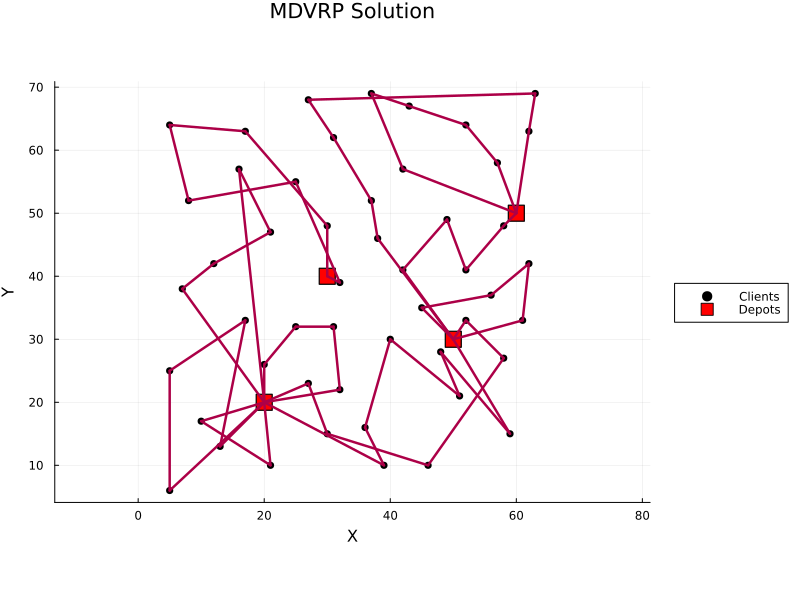

In [118]:
plot_mdvrp_solution(coord, x_val, client_num, depot_num)